In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"      : 140,
    "axes.titlesize"  : 14,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 12,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
})

In [3]:
PHASE_PALETTE = {
    "Powerplay (1–6)" : "#059bf5",
    "Middle (7–15)"   : "#f4d474",
    "Death (16–20)"   : "#0554bb",
}
VISUALS    = "../visuals"
phase_order = ["Powerplay (1–6)", "Middle (7–15)", "Death (16–20)"]

print("Libraries and config loaded")

Libraries and config loaded


In [4]:
df = pd.read_csv("../data/ipl_data.csv")

df["date"]         = pd.to_datetime(df["date"])
df["season"]       = df["date"].dt.year
df["over_cricket"] = df["over"] + 1  

def assign_phase(o):
    """Return T20 phase name from cricket over number (1–20)."""
    if   o <= 6 : return "Powerplay (1–6)"
    elif o <= 15: return "Middle (7–15)"
    else        : return "Death (16–20)"

df["phase"] = pd.Categorical(
    df["over_cricket"].apply(assign_phase),
    categories=phase_order, ordered=True
)

In [5]:
# Find which team batted first by finding the minimum ball number per team per match
innings_order = (
    df.groupby(["match_id", "batting_team"])["ball"]
      .min()
      .reset_index()
      .sort_values(["match_id", "ball"])
)
# Label 1st batting team as innings=1, 2nd as innings=2
innings_order["innings"] = innings_order.groupby("match_id").cumcount() + 1
df = df.merge(
    innings_order[["match_id", "batting_team", "innings"]],
    on=["match_id", "batting_team"], how="left"
)

In [6]:
# Per-innings final scores
innings_summary = (
    df.groupby(["match_id", "batting_team", "innings"])
      .agg(
          final_score   = ("innings_score",  "max"),
          final_wickets = ("innings_wickets", "max"),
          total_balls   = ("runs_total",      "count"),
      )
      .reset_index()
)

In [7]:
match_info = (
    df.drop_duplicates("match_id")
      [["match_id", "date", "season", "venue",
        "toss_winner", "toss_decision", "match_winner", "winning_outcome"]]
      .copy()
)

# Determine win method: "wickets" in outcome → chasing team won; else defending
match_info["win_method"] = match_info["winning_outcome"].apply(
    lambda x: "Chase" if "wicket" in str(x).lower() else "Defend"
)

# Attach 1st innings team & their score as the "target" for chasing team
first_inn = (innings_summary[innings_summary["innings"] == 1]
             [["match_id", "batting_team", "final_score"]]
             .rename(columns={"batting_team": "first_bat_team", "final_score": "target"}))
match_info = match_info.merge(first_inn, on="match_id", how="left")

# Attach 2nd innings team
second_inn = (innings_summary[innings_summary["innings"] == 2]
              [["match_id", "batting_team"]]
              .rename(columns={"batting_team": "second_bat_team"}))
match_info = match_info.merge(second_inn, on="match_id", how="left")

# Did the chasing team win?
match_info["chase_won"] = match_info["match_winner"] == match_info["second_bat_team"]

print(f"Data ready: {len(df):,} deliveries | "
      f"{df['match_id'].nunique():,} matches | "
      f"Seasons {df['season'].min()}–{df['season'].max()}")

Data ready: 278,205 deliveries | 1,169 matches | Seasons 2008–2025


## MODULE 1:BATTING vs BOWLING HEAD-TO-HEAD MATCHUPS

### Real team use: Set fielding plans, decide bowling rotations, and identify which bowler to bring on when a dangerous batter is in.

In [8]:
# Aggregate head-to-head stats for each batter-bowler pair
h2h = (
    df.groupby(["striker", "bowler"], observed=True)
      .agg(
          balls   = ("runs_batter", "count"),
          runs    = ("runs_batter", "sum"),
          wickets = ("is_wicket",   "sum"),
          dots    = ("runs_batter", lambda x: (x == 0).sum()),
          fours   = ("runs_batter", lambda x: (x == 4).sum()),
          sixes   = ("runs_batter", lambda x: (x == 6).sum()),
      )
      .reset_index()
)

In [9]:
# Minimum 12 balls for a statistically valid matchup
h2h = h2h[h2h["balls"] >= 12].copy()

In [10]:
# Derived metrics
h2h["strike_rate"]   = (h2h["runs"]    / h2h["balls"] * 100).round(1)
h2h["economy"]       = (h2h["runs"]    / h2h["balls"] * 6  ).round(2)
h2h["dot_pct"]       = (h2h["dots"]    / h2h["balls"] * 100).round(1)
h2h["boundary_pct"]  = ((h2h["fours"] + h2h["sixes"]) / h2h["balls"] * 100).round(1)
h2h["dismissal_rate"]= (h2h["wickets"] / h2h["balls"] * 6  ).round(3)

### Dominance Scores

In [11]:
# Batter Dominance (0–100): high SR + boundary % − dismissal risk
h2h["batter_dom"] = (
    (h2h["strike_rate"]   / h2h["strike_rate"].max()   * 60) +
    (h2h["boundary_pct"]  / h2h["boundary_pct"].max()  * 25) -
    (h2h["dismissal_rate"]/ h2h["dismissal_rate"].max()* 35)
).clip(0, 100).round(1)

# Bowler Dominance (0–100): high dots + wickets − conceded runs
h2h["bowler_dom"] = (
    (h2h["dot_pct"]       / h2h["dot_pct"].max()       * 40) +
    (h2h["dismissal_rate"]/ h2h["dismissal_rate"].max()* 40) -
    (h2h["strike_rate"]   / h2h["strike_rate"].max()   * 30)
).clip(0, 100).round(1)

print(f"Qualified matchups (≥12 balls): {len(h2h):,}")
print("\n Top 10 Batter-Dominated Matchups:")
print(h2h.nlargest(10, "batter_dom")
        [["striker","bowler","balls","runs","wickets","strike_rate","batter_dom"]]
        .to_string(index=False))
print("\n Top 10 Bowler-Dominated Matchups:")
print(h2h.nlargest(10, "bowler_dom")
        [["striker","bowler","balls","runs","wickets","strike_rate","bowler_dom"]]
        .to_string(index=False))

Qualified matchups (≥12 balls): 7,125

 Top 10 Batter-Dominated Matchups:
   striker       bowler  balls  runs  wickets  strike_rate  batter_dom
EJG Morgan     K Rabada     12    43        0        358.3        81.9
   M Vijay     S Narwal     17    58        0        341.2        81.4
  A Mhatre      B Kumar     12    38        0        316.7        78.0
 HH Pandya   AS Rajpoot     12    42        0        350.0        77.4
 HH Pandya       P Negi     12    39        0        325.0        76.3
  WG Jacks    MM Sharma     12    39        0        325.0        76.3
  DJ Hooda      S Gopal     12    38        0        316.7        71.8
JC Buttler Basil Thampi     14    42        0        300.0        71.6
 SP Narine     S Badree     16    48        0        300.0        71.3
GJ Maxwell      GB Hogg     13    39        0        300.0        70.4

 Top 10 Bowler-Dominated Matchups:
      striker          bowler  balls  runs  wickets  strike_rate  bowler_dom
     R Ashwin Harbhajan Singh   

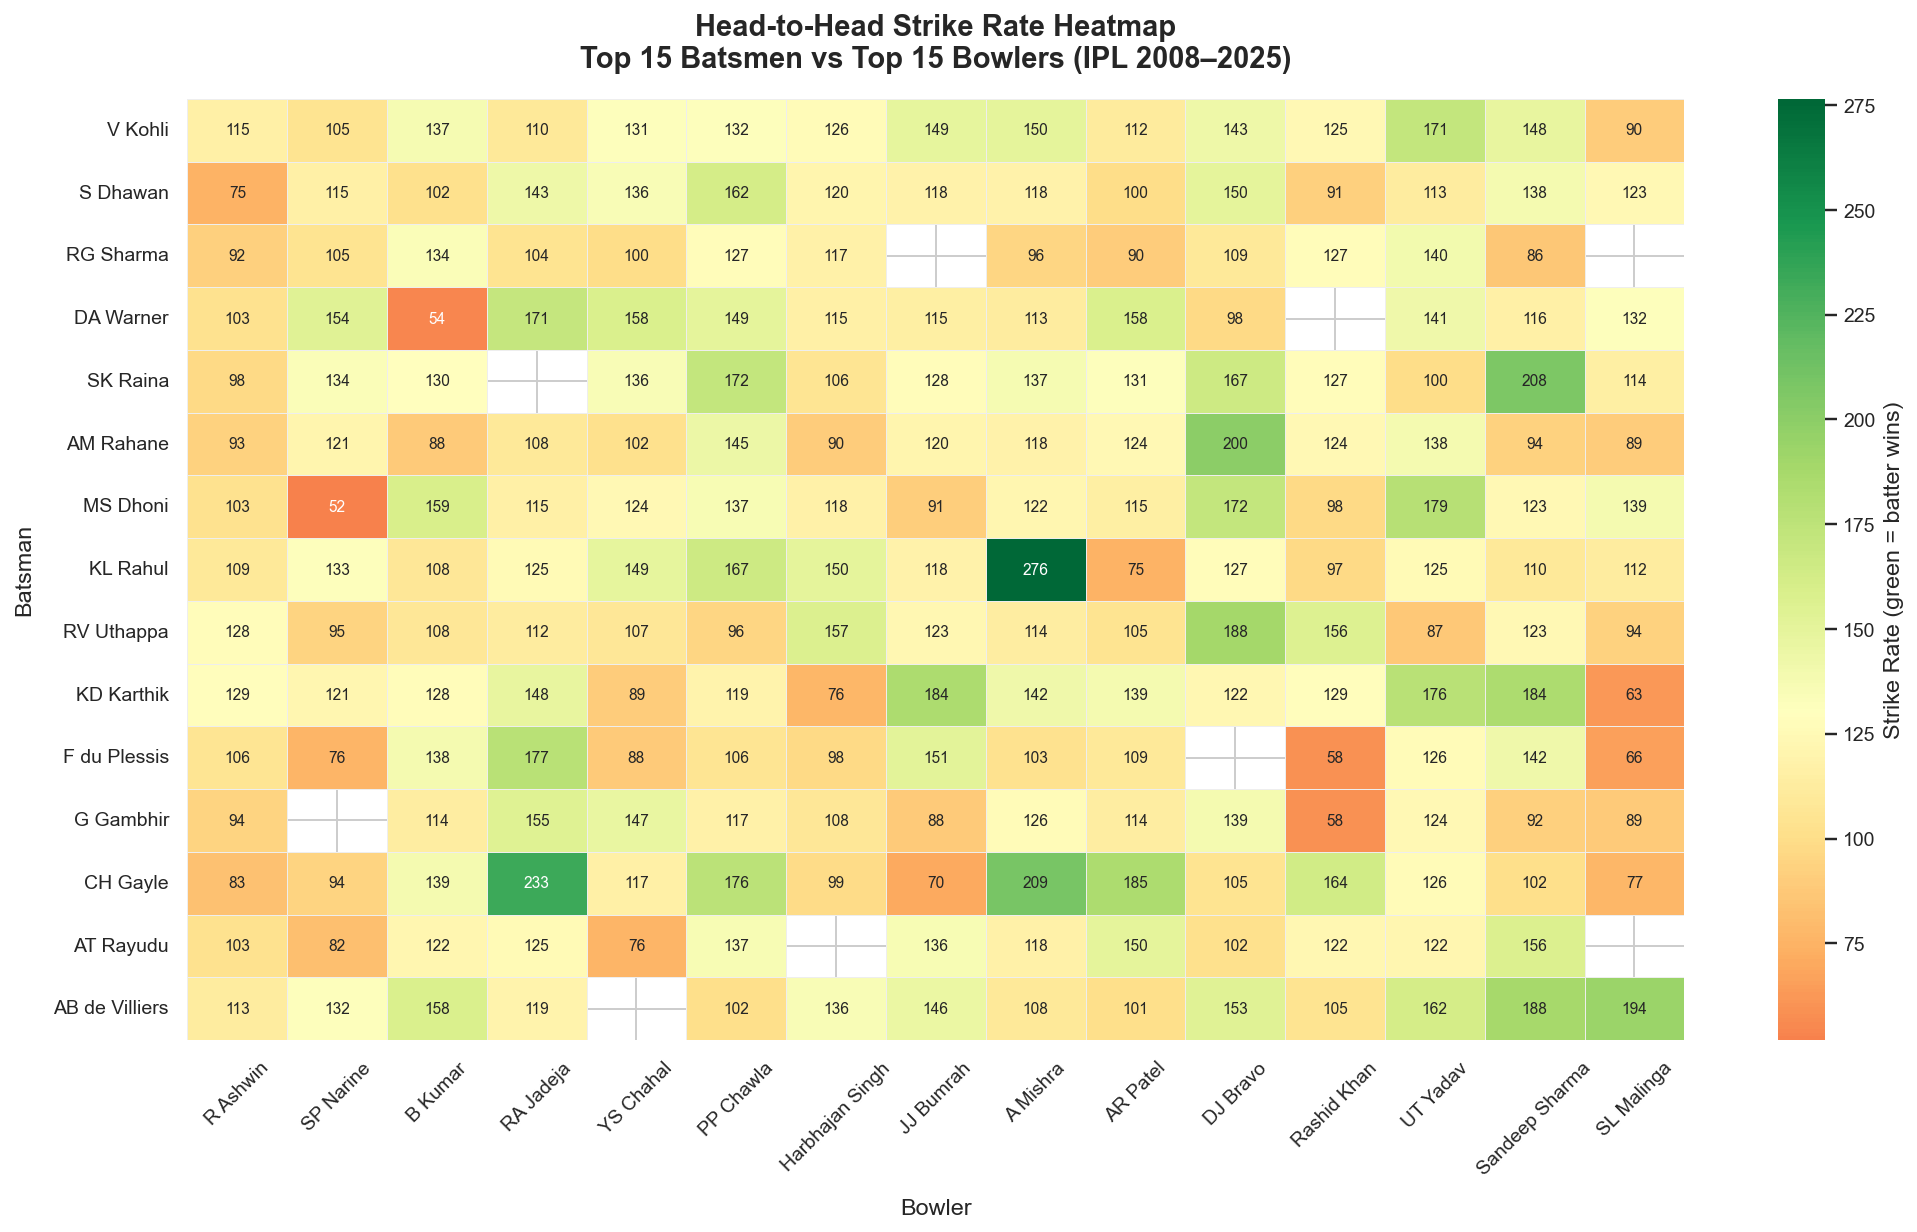


💡 STRATEGIC INSIGHT - Batting Matchups: Green cells = batsmen who dominate that bowler, these are the danger combinations a captain needs to plan for. Red cells show where the bowler has the upper hand, coaches build targeted plans like "bring Bowler X on when Batsman Y is at the crease." Grey cells are unknown matchups, a strategic blind spot that scouts work to fill.



In [12]:
# Select most-played batsmen and bowlers
top_batsmen = (df.groupby("striker")["runs_batter"].count()
                 .nlargest(15).index.tolist())
top_bowlers  = (df.groupby("bowler")["runs_total"].count()
                 .nlargest(15).index.tolist())

# Filter to only these matchups
hm = h2h[h2h["striker"].isin(top_batsmen) & h2h["bowler"].isin(top_bowlers)].copy()

# Pivot to matrix: rows = batsmen, cols = bowlers, values = strike rate
pivot_sr = (
    hm.pivot_table(index="striker", columns="bowler",
                   values="strike_rate", aggfunc="mean")
      .reindex(index=top_batsmen, columns=top_bowlers)
)

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(
    pivot_sr,
    ax=ax,
    cmap="RdYlGn",            # red = bowler wins, green = batter wins
    center=130,               # league average SR ~130
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    linecolor="#eeeeee",
    cbar_kws={"label": "Strike Rate (green = batter wins)"},
    annot_kws={"size": 8},
    mask=pivot_sr.isna(),     # grey out unknown matchups
)
ax.set_title(
    "Head-to-Head Strike Rate Heatmap\nTop 15 Batsmen vs Top 15 Bowlers (IPL 2008–2025)",
    pad=16, fontsize=15
)
ax.set_xlabel("Bowler", labelpad=10)
ax.set_ylabel("Batsman", labelpad=10)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_01_matchup_heatmap.png", bbox_inches="tight")
plt.show()

print("""
💡 STRATEGIC INSIGHT - Batting Matchups: Green cells = batsmen who dominate that bowler, these are the danger combinations a captain needs to plan for. Red cells show where the bowler has the upper hand, coaches build targeted plans like "bring Bowler X on when Batsman Y is at the crease." Grey cells are unknown matchups, a strategic blind spot that scouts work to fill.
""")

### Phase-Wise Bowler Economy

In [15]:
# Aggregate per bowler per phase
phase_bowler = (
    df.groupby(["bowler", "phase"], observed=True)
      .agg(
          balls   = ("runs_total", "count"),
          runs    = ("runs_total", "sum"),
          wickets = ("is_wicket",  "sum"),
      )
      .reset_index()
)
phase_bowler["economy"] = (phase_bowler["runs"] / phase_bowler["balls"] * 6).round(2)
phase_bowler["overs"]   = (phase_bowler["balls"] / 6).round(1)

In [16]:
# Qualify: min 20 overs per phase
qual = phase_bowler[phase_bowler["overs"] >= 20].copy()

# Pivot: one row per bowler, one column per phase
econ_pivot = (
    qual.pivot_table(index="bowler", columns="phase",
                     values="economy", aggfunc="mean")
        .dropna()  # keep only bowlers with data in ALL 3 phases
)
# Top 10 most economical Powerplay bowlers with all-phase data shown
top_versatile = econ_pivot.nsmallest(10, "Powerplay (1–6)").reset_index()

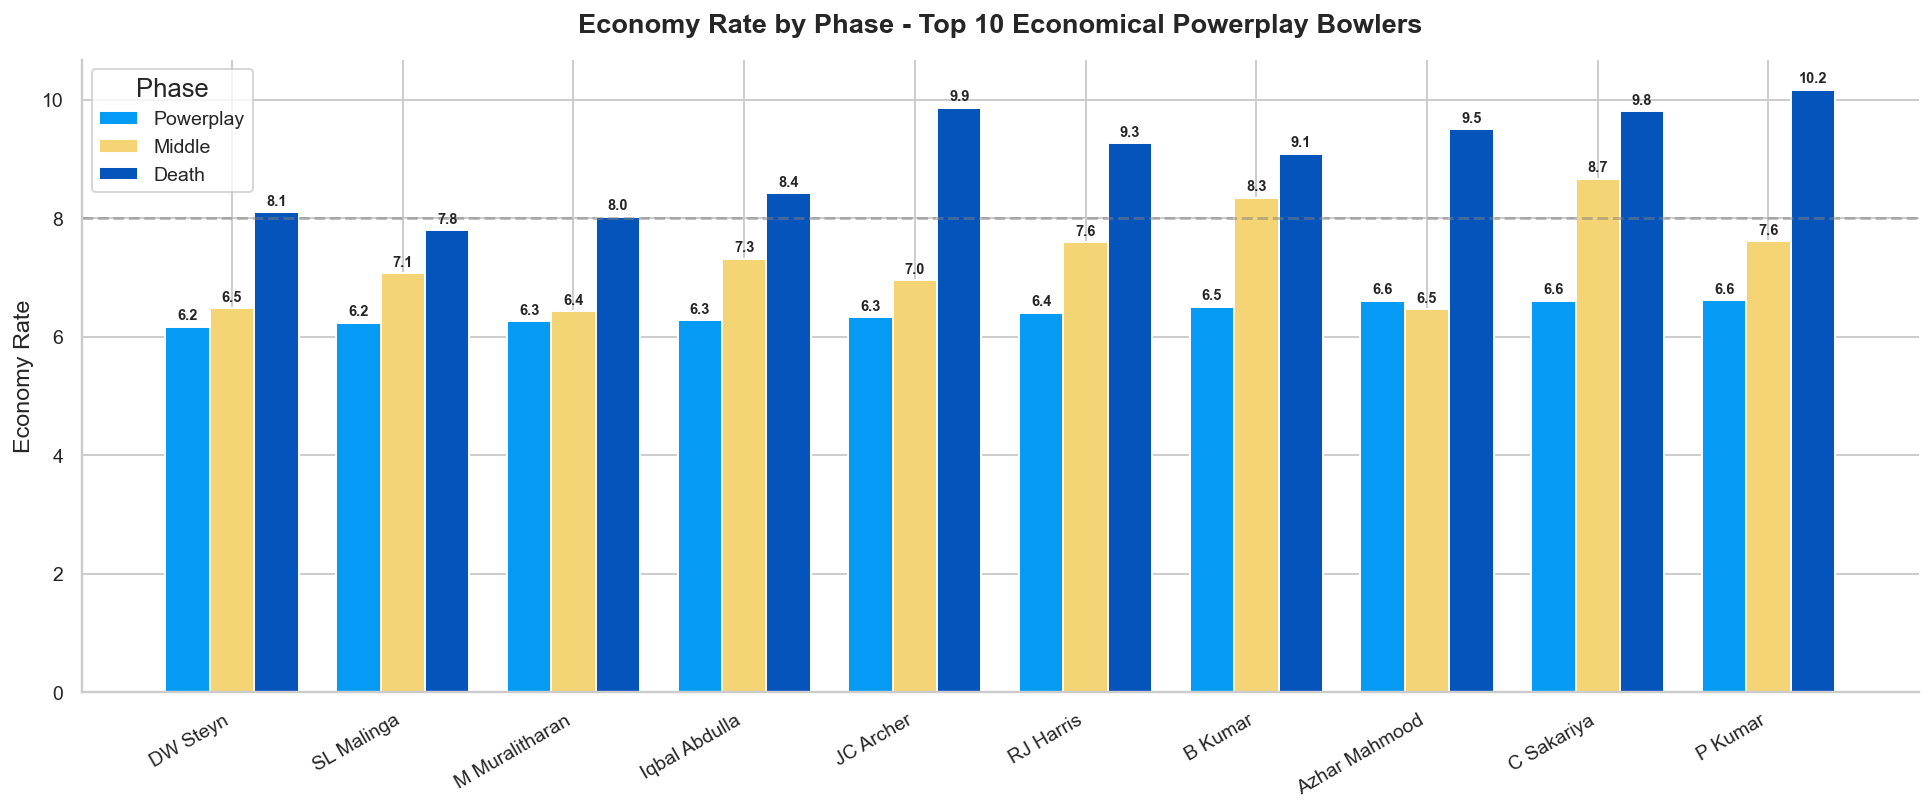


💡 STRATEGIC INSIGHT - Bowler Phase Effectiveness: Bowlers who stay under 8 RPO across all phases are extremely rare and command top auction prices. Most are specialists, great in one or two phases but expensive in others. A smart team builds a bowling attack where specialists complement each other: swing pacers for Powerplay, spinners/medium pace for Middle, yorker experts for Death.



In [18]:
x     = np.arange(len(top_versatile))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, top_versatile["Powerplay (1–6)"], width,
            label="Powerplay", color=PHASE_PALETTE["Powerplay (1–6)"], edgecolor="white")
b2 = ax.bar(x,          top_versatile["Middle (7–15)"],  width,
            label="Middle",    color=PHASE_PALETTE["Middle (7–15)"],   edgecolor="white")
b3 = ax.bar(x + width,  top_versatile["Death (16–20)"],  width,
            label="Death",     color=PHASE_PALETTE["Death (16–20)"],   edgecolor="white")

for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(top_versatile["bowler"], rotation=30, ha="right")
ax.set_title("Economy Rate by Phase - Top 10 Economical Powerplay Bowlers", pad=14)
ax.set_ylabel("Economy Rate")
ax.legend(title="Phase", fontsize=10)
ax.axhline(y=8, color="grey", linestyle="--", alpha=0.5, label="Economy = 8 benchmark")
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_02_bowler_phase_economy.png", bbox_inches="tight")
plt.show()

print("""
💡 STRATEGIC INSIGHT - Bowler Phase Effectiveness: Bowlers who stay under 8 RPO across all phases are extremely rare and command top auction prices. Most are specialists, great in one or two phases but expensive in others. A smart team builds a bowling attack where specialists complement each other: swing pacers for Powerplay, spinners/medium pace for Middle, yorker experts for Death.
""")

## MODULE 2 - VENUE & PITCH IMPACT

### Real team use: Toss decisions, team selection (extra pacer vs spinner), par score benchmarks, and pitch-specific game plans.

In [19]:
venue_map = {
    "Wankhede Stadium, Mumbai"                            : "Wankhede Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai"            : "MA Chidambaram Stadium, Chepauk",
    "MA Chidambaram Stadium"                              : "MA Chidambaram Stadium, Chepauk",
    "Punjab Cricket Association Stadium, Mohali"          : "PCA Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "PCA Stadium, Mohali",
    "Rajiv Gandhi International Stadium, Uppal"           : "Rajiv Gandhi Intl Stadium",
    "Rajiv Gandhi International Stadium"                  : "Rajiv Gandhi Intl Stadium",
}
df["venue_clean"] = df["venue"].replace(venue_map)

In [20]:
# Per-innings stats per venue
venue_innings = (
    df.groupby(["match_id", "venue_clean", "batting_team"])
      .agg(
          final_score   = ("innings_score",  "max"),
          total_balls   = ("runs_total",     "count"),
          total_wickets = ("is_wicket",      "sum"),
          sixes         = ("runs_batter",    lambda x: (x == 6).sum()),
          fours         = ("runs_batter",    lambda x: (x == 4).sum()),
          dots          = ("runs_batter",    lambda x: (x == 0).sum()),
      )
      .reset_index()
)

In [21]:
# Aggregate to venue level
venue_stats = (
    venue_innings
      .groupby("venue_clean")
      .agg(
          innings      = ("final_score",   "count"),
          avg_score    = ("final_score",   "mean"),
          avg_wickets  = ("total_wickets", "mean"),
          total_sixes  = ("sixes",         "sum"),
          total_fours  = ("fours",         "sum"),
          total_balls  = ("total_balls",   "sum"),
          total_dots   = ("dots",          "sum"),
      )
      .reset_index()
)

In [22]:
# Keep venues with enough data
venue_stats = venue_stats[venue_stats["innings"] >= 50].copy()

venue_stats["boundary_pct"] = (
    (venue_stats["total_sixes"] + venue_stats["total_fours"])
    / venue_stats["total_balls"] * 100
).round(1)
venue_stats["dot_pct"] = (
    venue_stats["total_dots"] / venue_stats["total_balls"] * 100
).round(1)

### Batting Friendliness Index (0–100)

In [23]:
# High score + high boundary % + low dot % → batting-friendly
venue_stats["batting_index"] = (
    (venue_stats["avg_score"]    / venue_stats["avg_score"].max()    * 50) +
    (venue_stats["boundary_pct"] / venue_stats["boundary_pct"].max() * 30) +
    ((1 - venue_stats["dot_pct"] / venue_stats["dot_pct"].max())     * 20)
).round(1)

venue_stats = venue_stats.sort_values("batting_index", ascending=False)

print("Top 10 Most Batting-Friendly Venues:")
print(venue_stats.head(10)[
    ["venue_clean", "innings", "avg_score", "boundary_pct", "dot_pct", "batting_index"]
].to_string(index=False))

Top 10 Most Batting-Friendly Venues:
                        venue_clean  innings  avg_score  boundary_pct  dot_pct  batting_index
   Narendra Modi Stadium, Ahmedabad       66 178.363636          18.9     36.3           82.4
                   Wankhede Stadium      250 165.216000          17.8     40.8           74.8
                PCA Stadium, Mohali       92 157.956522          16.3     37.7           71.9
              M Chinnaswamy Stadium      129 156.875969          17.5     41.2           71.8
                   Feroz Shah Kotla      119 154.798319          16.5     39.3           70.5
                       Eden Gardens      154 153.623377          16.9     41.0           70.0
Dubai International Cricket Stadium       92 156.423913          15.0     39.2           68.6
    MA Chidambaram Stadium, Chepauk      182 156.983516          15.0     39.5           68.6
          Rajiv Gandhi Intl Stadium      128 152.218750          15.3     39.7           67.7
               Sheikh Z

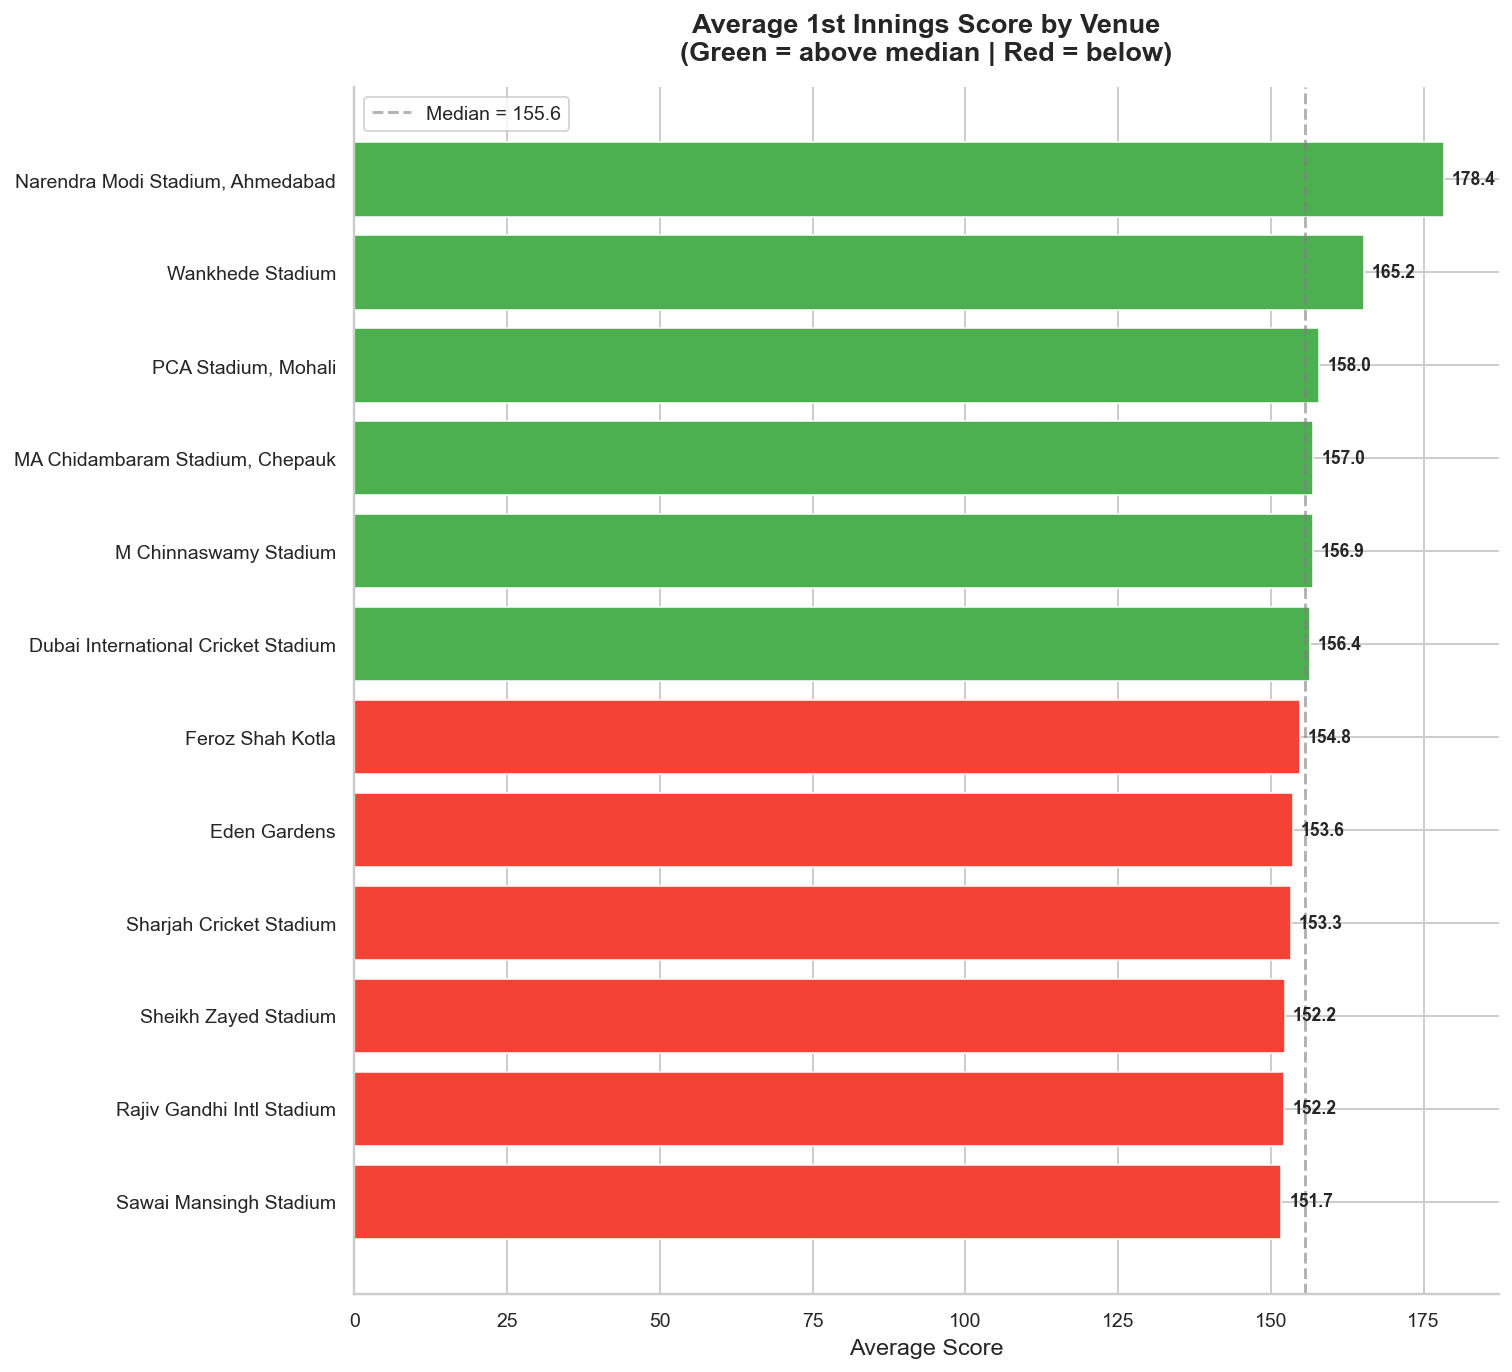

In [24]:
# Chart 1: Average score by venue - top & bottom 12
top12    = venue_stats.nlargest(12,  "avg_score")
bottom12 = venue_stats.nsmallest(12, "avg_score")
combined = (pd.concat([top12, bottom12])
              .drop_duplicates("venue_clean")
              .sort_values("avg_score", ascending=True))

median_score = venue_stats["avg_score"].median()
bar_colors   = ["#F44336" if s < median_score else "#4CAF50"
                for s in combined["avg_score"]]

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(combined["venue_clean"], combined["avg_score"],
               color=bar_colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9, fontweight="bold")
ax.axvline(median_score, color="grey", linestyle="--", alpha=0.6,
           label=f"Median = {median_score:.1f}")
ax.set_title("Average 1st Innings Score by Venue\n"
             "(Green = above median | Red = below)", pad=14)
ax.set_xlabel("Average Score")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_03_venue_avg_score.png", bbox_inches="tight")
plt.show()

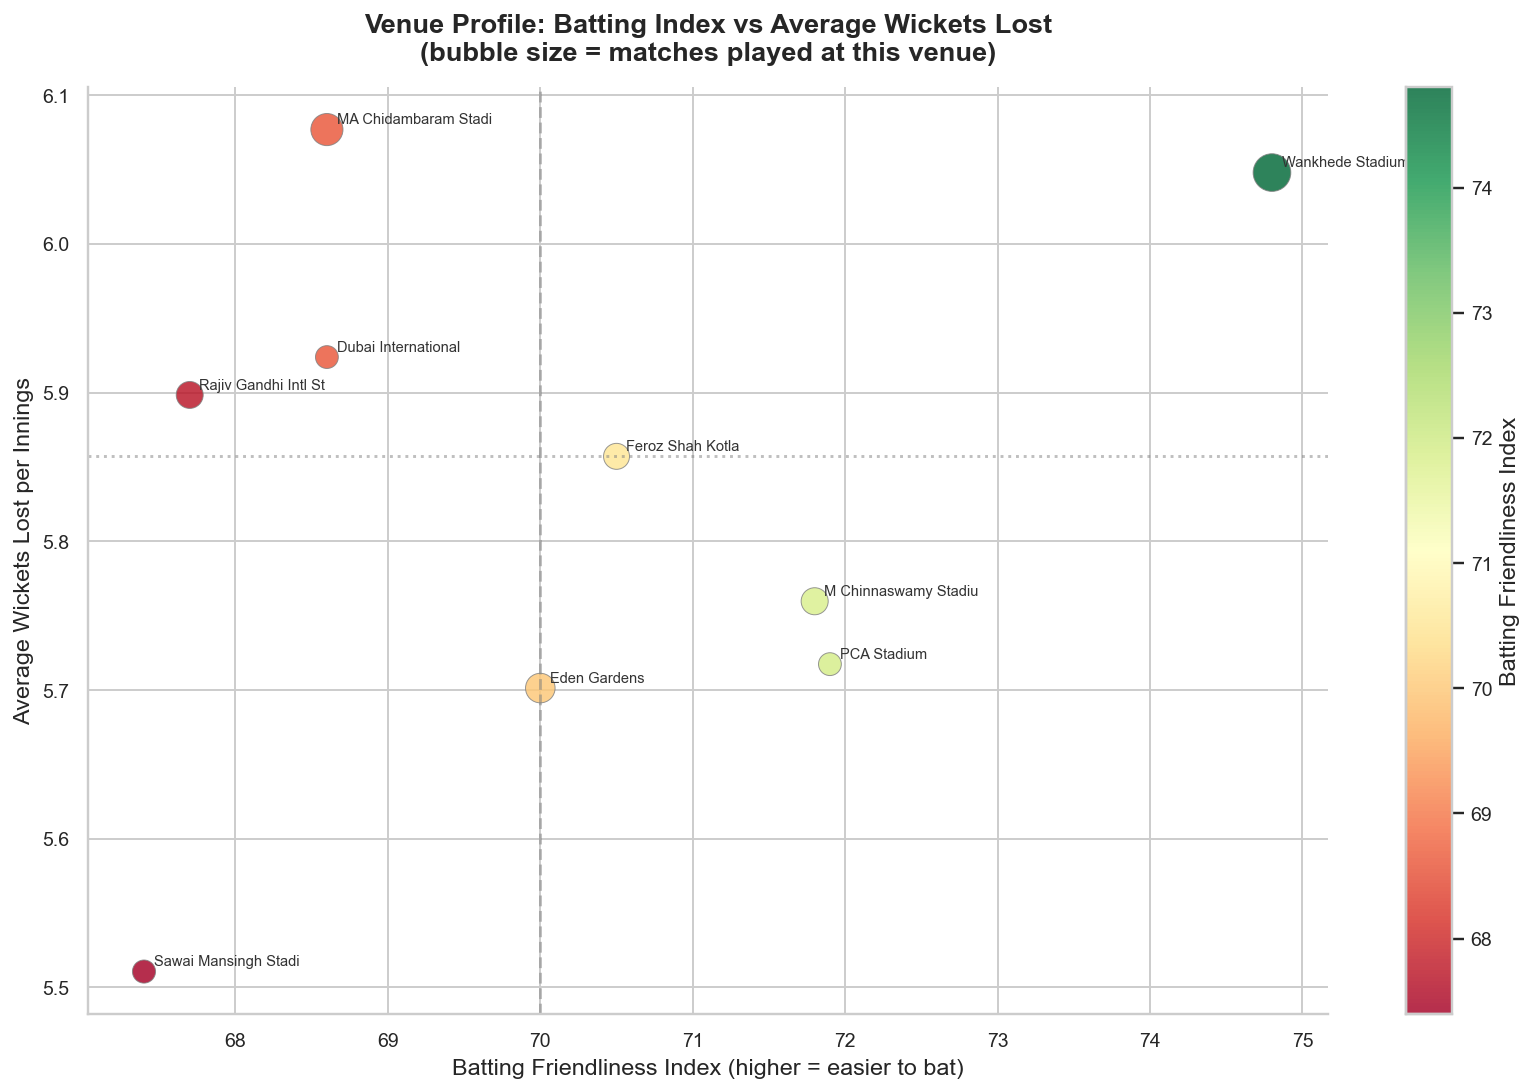


💡 STRATEGIC INSIGHT - Venue & Pitch Impact:
   Top-right venues (high batting index + high wickets) are high-variance, high-entertainment grounds, where both big scores and wickets are common.
   Bottom-left venues produce tight, low-scoring tactical battles. Teams with power-hitters love high-index venues; bowling attacks with death specialists prefer low-index grounds. Always check venue history before finalising team selection and toss strategy.



In [25]:
# Chart 2: Batting Index vs Average Wickets scatter
top_venues = venue_stats[venue_stats["innings"] >= 80].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    top_venues["batting_index"],
    top_venues["avg_wickets"],
    s=top_venues["innings"] * 1.5,
    c=top_venues["batting_index"],
    cmap="RdYlGn",
    alpha=0.82,
    edgecolors="grey",
    linewidths=0.5,
)
for _, row in top_venues.iterrows():
    ax.annotate(
        row["venue_clean"].split(",")[0][:20],
        xy=(row["batting_index"], row["avg_wickets"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7.5, color="#333333"
    )
plt.colorbar(sc, ax=ax, label="Batting Friendliness Index")
ax.axvline(top_venues["batting_index"].median(), color="grey",
           linestyle="--", alpha=0.5)
ax.axhline(top_venues["avg_wickets"].median(),  color="grey",
           linestyle=":",  alpha=0.5)
ax.set_title("Venue Profile: Batting Index vs Average Wickets Lost\n"
             "(bubble size = matches played at this venue)", pad=14)
ax.set_xlabel("Batting Friendliness Index (higher = easier to bat)")
ax.set_ylabel("Average Wickets Lost per Innings")
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_04_venue_profile_scatter.png", bbox_inches="tight")
plt.show()

print("""
💡 STRATEGIC INSIGHT - Venue & Pitch Impact:
   Top-right venues (high batting index + high wickets) are high-variance, high-entertainment grounds, where both big scores and wickets are common.
   Bottom-left venues produce tight, low-scoring tactical battles. Teams with power-hitters love high-index venues; bowling attacks with death specialists prefer low-index grounds. Always check venue history before finalising team selection and toss strategy.
""")

## MODULE 3 - CHASING vs DEFENDING WIN RATES

### Real team use: Toss decisions, par score targets, and pacing strategy when batting first or second.

In [26]:
# Overall chase vs defend split
overall = match_info["chase_won"].value_counts(normalize=True) * 100
print("Overall Win Rate:")
print(f"  Chasing  : {overall.get(True,  0):.1f}%")
print(f"  Defending: {overall.get(False, 0):.1f}%")
print(f"  Matches  : {len(match_info):,}")

# Win rate bucketed by first-innings target score
bins   = [0, 130, 150, 165, 180, 200, 220, 300]
labels = ["<130", "130–150", "150–165", "165–180",
          "180–200", "200–220", "220+"]

match_info["target_bracket"] = pd.cut(
    match_info["target"], bins=bins, labels=labels, right=True
)

bracket_wr = (
    match_info
      .groupby("target_bracket", observed=True)["chase_won"]
      .agg(total_matches="count", chases_won="sum")
      .assign(
          chase_win_pct  = lambda x: (x["chases_won"] / x["total_matches"] * 100).round(1)
      )
      .reset_index()
)
bracket_wr["defend_win_pct"] = (100 - bracket_wr["chase_win_pct"]).round(1)

print("\nChase vs Defend Win Rate by Target Bracket:")
print(bracket_wr.to_string(index=False))

Overall Win Rate:
  Chasing  : 49.4%
  Defending: 50.6%
  Matches  : 1,169

Chase vs Defend Win Rate by Target Bracket:
target_bracket  total_matches  chases_won  chase_win_pct  defend_win_pct
          <130            188         118           62.8            37.2
       130–150            237         134           56.5            43.5
       150–165            237         123           51.9            48.1
       165–180            193          91           47.2            52.8
       180–200            192          74           38.5            61.5
       200–220             85          28           32.9            67.1
          220+             37          10           27.0            73.0


### Chase Defend Charts

Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/akshitasiddhapura/Desktop/ipl_phase_analysis/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-162' coro=<Kernel.shell_main() running at /Users/akshitasiddhapura/Desktop/ipl_phase_analysis/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/akshitasiddhapura/Desktop/ipl_phase_analysis/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-162' coro=<Kernel.shell_main() running at /Users/akshitasiddhapura/Desktop/ipl_phase_analysis/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


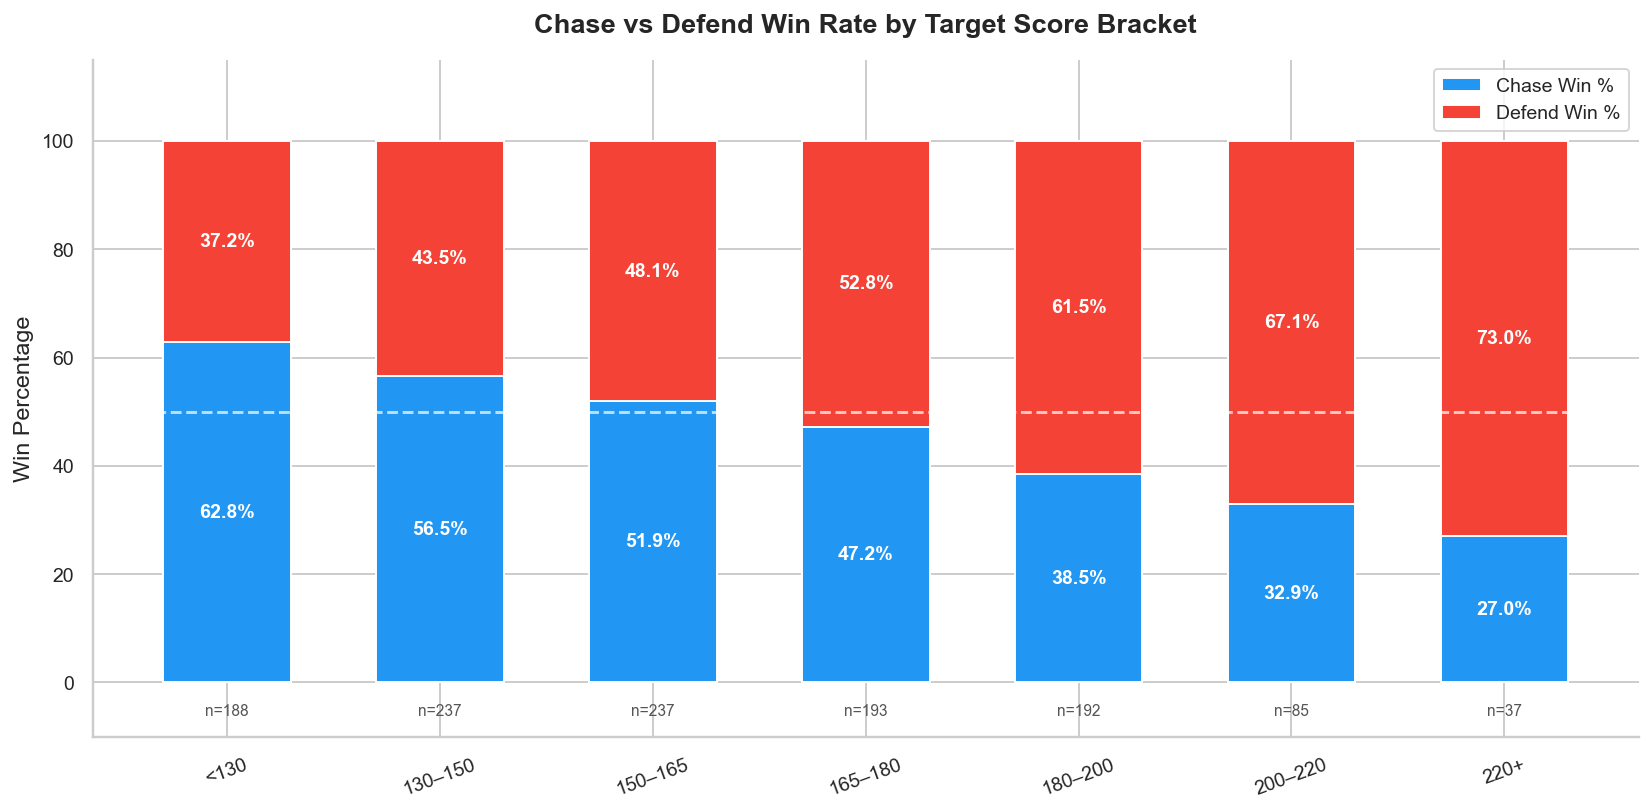

In [27]:
# Chart 1: Stacked bar - Chase vs Defend by target bracket
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bracket_wr))

b1 = ax.bar(x, bracket_wr["chase_win_pct"],
            label="Chase Win %",  color="#2196F3", width=0.6, edgecolor="white")
b2 = ax.bar(x, bracket_wr["defend_win_pct"],
            bottom=bracket_wr["chase_win_pct"],
            label="Defend Win %", color="#F44336", width=0.6, edgecolor="white")

# Labels inside bars
for i, row in bracket_wr.iterrows():
    ax.text(i, row["chase_win_pct"] / 2,
            f"{row['chase_win_pct']:.1f}%",
            ha="center", va="center", fontsize=10,
            fontweight="bold", color="white")
    ax.text(i, row["chase_win_pct"] + row["defend_win_pct"] / 2,
            f"{row['defend_win_pct']:.1f}%",
            ha="center", va="center", fontsize=10,
            fontweight="bold", color="white")
    ax.text(i, -6, f"n={row['total_matches']}",
            ha="center", fontsize=8, color="#555555")

ax.axhline(y=50, color="white", linestyle="--", lw=1.5, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(bracket_wr["target_bracket"], rotation=20)
ax.set_title("Chase vs Defend Win Rate by Target Score Bracket", pad=14)
ax.set_ylabel("Win Percentage")
ax.set_ylim(-10, 115)
ax.legend(loc="upper right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_05_chase_defend_brackets.png", bbox_inches="tight")
plt.show()


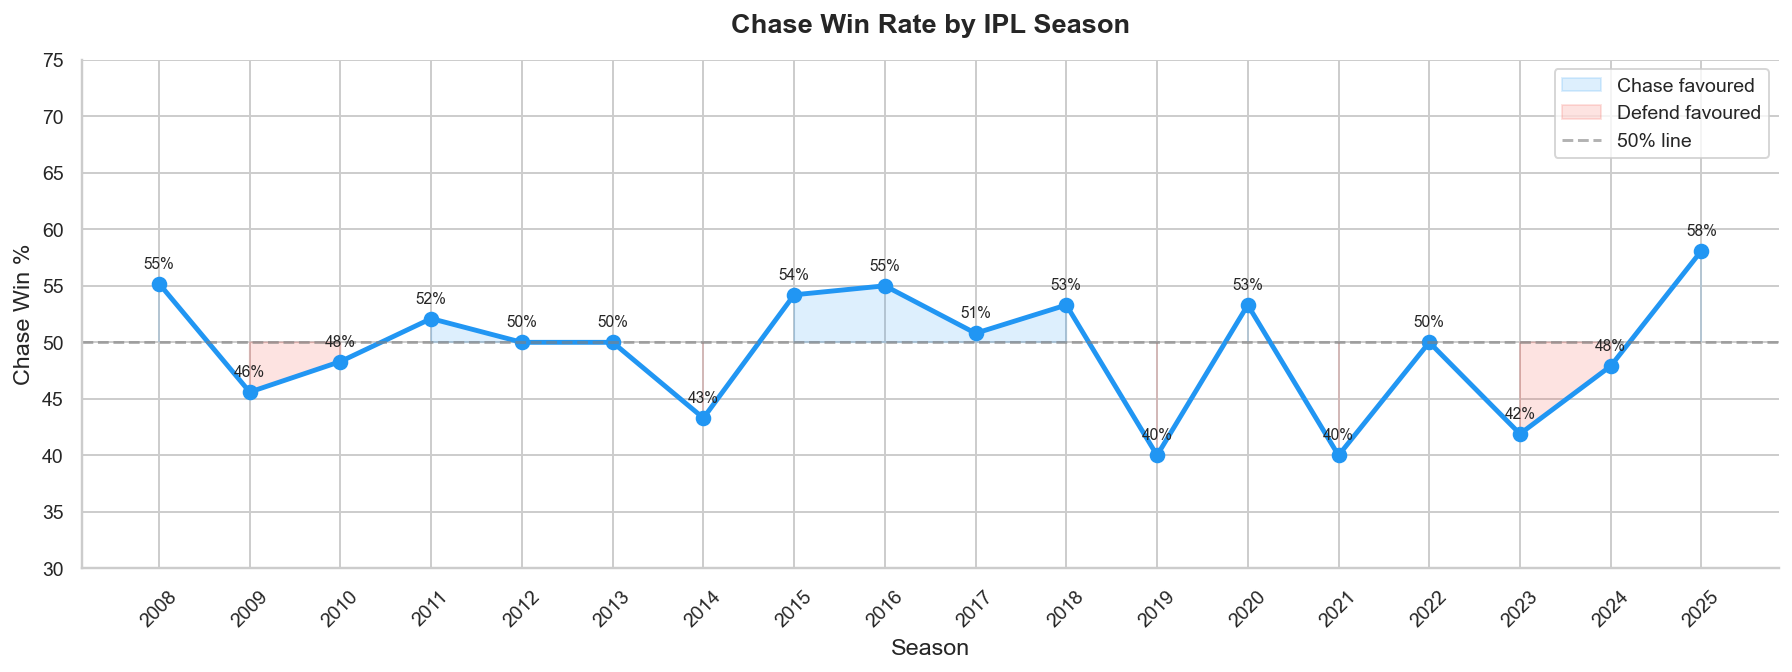


💡 STRATEGIC INSIGHT - Chase vs Defend
   The stacked bar chart reveals the critical tipping points:
   - Totals below 165 → chasing team holds the advantage
   - 165–180 → near coin-flip; batting conditions on the night matter
   - Above 185 → defending team has a significant edge
   - 200+ → almost always defended successfully
   The seasonal trend shows how this has evolved — modern teams with better data and aggressive batting have improved chase success rates.



In [28]:
# Chart 2: Chase win rate trend across seasons
season_chase = (
    match_info
      .groupby("season")["chase_won"]
      .agg(total="count", chases_won="sum")
      .assign(chase_pct=lambda x: (x["chases_won"] / x["total"] * 100).round(1))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(season_chase["season"], season_chase["chase_pct"],
        marker="o", lw=2.5, color="#2196F3", markersize=7)
ax.fill_between(season_chase["season"], season_chase["chase_pct"], 50,
                where=season_chase["chase_pct"] >= 50,
                alpha=0.15, color="#2196F3", label="Chase favoured")
ax.fill_between(season_chase["season"], season_chase["chase_pct"], 50,
                where=season_chase["chase_pct"] <  50,
                alpha=0.15, color="#F44336", label="Defend favoured")
ax.axhline(50, color="grey", linestyle="--", lw=1.5, alpha=0.6, label="50% line")
for _, row in season_chase.iterrows():
    ax.annotate(f"{row['chase_pct']:.0f}%",
                xy=(row["season"], row["chase_pct"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8)
ax.set_title("Chase Win Rate by IPL Season", pad=14)
ax.set_xlabel("Season")
ax.set_ylabel("Chase Win %")
ax.set_xticks(season_chase["season"])
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=10)
ax.set_ylim(30, 75)
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_06_chase_win_trend.png", bbox_inches="tight")
plt.show()

print("""
💡 STRATEGIC INSIGHT - Chase vs Defend
   The stacked bar chart reveals the critical tipping points:
   - Totals below 165 → chasing team holds the advantage
   - 165–180 → near coin-flip; batting conditions on the night matter
   - Above 185 → defending team has a significant edge
   - 200+ → almost always defended successfully
   The seasonal trend shows how this has evolved — modern teams with better data and aggressive batting have improved chase success rates.
""")

### Required Run Rate Analysis: At what over-15 RRR does a chase become near-impossible? Teams use this to pace their 2nd innings batting.

In [29]:
# Get 2nd innings deliveries only
chase_df  = df[df["innings"] == 2].copy()
chase_meta = match_info[["match_id", "target", "chase_won"]].copy()
checkpoints = [6, 10, 15]

# Calculate innings score at each checkpoint and resulting RRR
rows = []
for match_id, grp in chase_df.groupby("match_id"):
    meta = chase_meta[chase_meta["match_id"] == match_id]
    if len(meta) == 0:
        continue
    target    = meta["target"].values[0]
    chase_won = meta["chase_won"].values[0]
    row       = {"match_id": match_id, "target": target, "chase_won": chase_won}
    for cp in checkpoints:
        sub = grp[grp["over_cricket"] <= cp]
        if len(sub) > 0:
            score_at       = sub["innings_score"].max()
            remaining_balls = (20 - cp) * 6
            row[f"score_at_{cp}"] = score_at
            row[f"rrr_at_{cp}"]   = round((target - score_at) / (remaining_balls / 6), 2)
        else:
            row[f"score_at_{cp}"] = np.nan
            row[f"rrr_at_{cp}"]   = np.nan
    rows.append(row)

rrr_df = pd.DataFrame(rows)

In [30]:
# Bucket by RRR at over 15 (entering final 5 overs - most predictive checkpoint)
rrr_df["rrr_15_bracket"] = pd.cut(
    rrr_df["rrr_at_15"],
    bins=[0, 6, 8, 10, 12, 15, 50],
    labels=["<6", "6–8", "8–10", "10–12", "12–15", "15+"]
)

rrr_win = (
    rrr_df
      .groupby("rrr_15_bracket", observed=True)["chase_won"]
      .agg(matches="count", wins="sum")
      .assign(win_pct=lambda x: (x["wins"] / x["matches"] * 100).round(1))
      .reset_index()
)

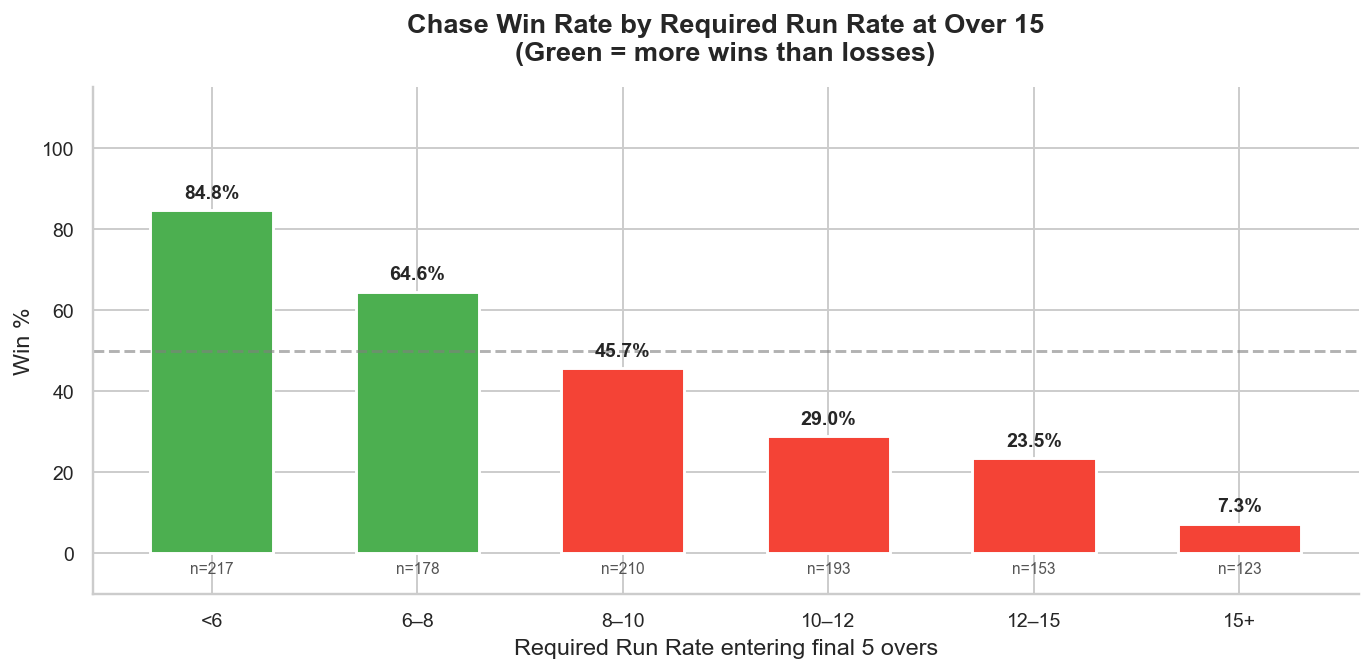


💡 STRATEGIC INSIGHT — Required Run Rate at Over 15
   The data draws a clear line:
   - RRR < 8 at over 15 → team is in control; likely to win
   - RRR 8–10 → competitive but challenging; needs boundaries in death
   - RRR > 10 → win probability below 30%; need something special
   - RRR > 12 → almost certain defeat
   This guides captains: if batting 2nd, the goal is to stay inside 8 RPO after 15 overs with at least 4 wickets in hand.



In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#4CAF50" if p >= 50 else "#F44336" for p in rrr_win["win_pct"]]
bars = ax.bar(rrr_win["rrr_15_bracket"], rrr_win["win_pct"],
              color=bar_colors, width=0.6, edgecolor="white", linewidth=1.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10, fontweight="bold")
for i, row in rrr_win.iterrows():
    ax.text(i, -5, f"n={row['matches']}", ha="center", fontsize=8, color="#555")
ax.axhline(50, color="grey", linestyle="--", lw=1.5, alpha=0.6)
ax.set_title("Chase Win Rate by Required Run Rate at Over 15\n"
             "(Green = more wins than losses)", pad=14)
ax.set_xlabel("Required Run Rate entering final 5 overs")
ax.set_ylabel("Win %")
ax.set_ylim(-10, 115)
sns.despine()
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_07_rrr_win_rate.png", bbox_inches="tight")
plt.show()

print("""
💡 STRATEGIC INSIGHT — Required Run Rate at Over 15
   The data draws a clear line:
   - RRR < 8 at over 15 → team is in control; likely to win
   - RRR 8–10 → competitive but challenging; needs boundaries in death
   - RRR > 10 → win probability below 30%; need something special
   - RRR > 12 → almost certain defeat
   This guides captains: if batting 2nd, the goal is to stay inside 8 RPO after 15 overs with at least 4 wickets in hand.
""")

## MODULE 4 — BOWLER PHASE EFFECTIVENESS (DEEP DIVE)

### Real team use: Goes beyond economy/wickets to measure how much PRESSURE a bowler creates — dot balls build psychological pressure that leads to wickets and run-rate collapses.

### Pressure Index formula:(dot_ball_pct × 0.40) + (wicket_rate × 0.40) − (economy/max × 0.20)

In [32]:
pressure = (
    df.groupby(["bowler", "phase"], observed=True)
      .agg(
          balls       = ("runs_total", "count"),
          runs        = ("runs_total", "sum"),
          wickets     = ("is_wicket",  "sum"),
          dots        = ("runs_total", lambda x: (x == 0).sum()),
          fours_given = ("runs_batter", lambda x: (x == 4).sum()),
          sixes_given = ("runs_batter", lambda x: (x == 6).sum()),
      )
      .reset_index()
)

pressure["overs"]    = (pressure["balls"] / 6).round(1)
pressure["economy"]  = (pressure["runs"]  / pressure["balls"] * 6).round(2)
pressure["dot_pct"]  = (pressure["dots"]  / pressure["balls"] * 100).round(1)
pressure["wkt_rate"] = (pressure["wickets"] / pressure["balls"] * 6).round(3)
pressure["boundary_concede_pct"] = (
    (pressure["fours_given"] + pressure["sixes_given"]) / pressure["balls"] * 100
).round(1)

In [33]:
# Normalise components 0–1 before combining
for col in ["dot_pct", "wkt_rate", "economy"]:
    pressure[f"{col}_norm"] = pressure[col] / pressure[col].max()

# Pressure Index: reward dots + wickets, penalise economy
pressure["pressure_index"] = (
    pressure["dot_pct_norm"]  * 0.40 +
    pressure["wkt_rate_norm"] * 0.40 -
    pressure["economy_norm"]  * 0.20
).round(3)

# Qualify: min 15 overs per phase
pressure_qual = pressure[pressure["overs"] >= 15].copy()

for phase in phase_order:
    sub = pressure_qual[pressure_qual["phase"] == phase]
    top = sub.nlargest(8, "pressure_index")
    print(f"\nTop 8 Pressure Bowlers — {phase}:")
    print(top[["bowler", "overs", "economy", "dot_pct",
               "wkt_rate", "boundary_concede_pct", "pressure_index"]]
            .to_string(index=False))


Top 8 Pressure Bowlers — Powerplay (1–6):
       bowler  overs  economy  dot_pct  wkt_rate  boundary_concede_pct  pressure_index
   WPUJC Vaas   33.3     6.33     56.5     0.510                  17.5           0.225
     A Kumble   18.2     4.95     58.7     0.165                  11.0           0.218
    R Rampaul   27.7     5.89     56.6     0.361                  15.1           0.218
   GD McGrath   37.7     5.79     56.2     0.239                  14.2           0.209
    IC Pandey   44.8     6.96     56.1     0.268                  20.1           0.204
CK Langeveldt   15.0     6.60     52.2     0.400                  16.7           0.199
BW Hilfenhaus   42.0     6.19     52.8     0.310                  13.9           0.197
    A Symonds   19.7     5.59     52.5     0.254                  11.9           0.196

Top 8 Pressure Bowlers — Middle (7–15):
         bowler  overs  economy  dot_pct  wkt_rate  boundary_concede_pct  pressure_index
    Shivam Mavi   27.8     6.65     42.5    

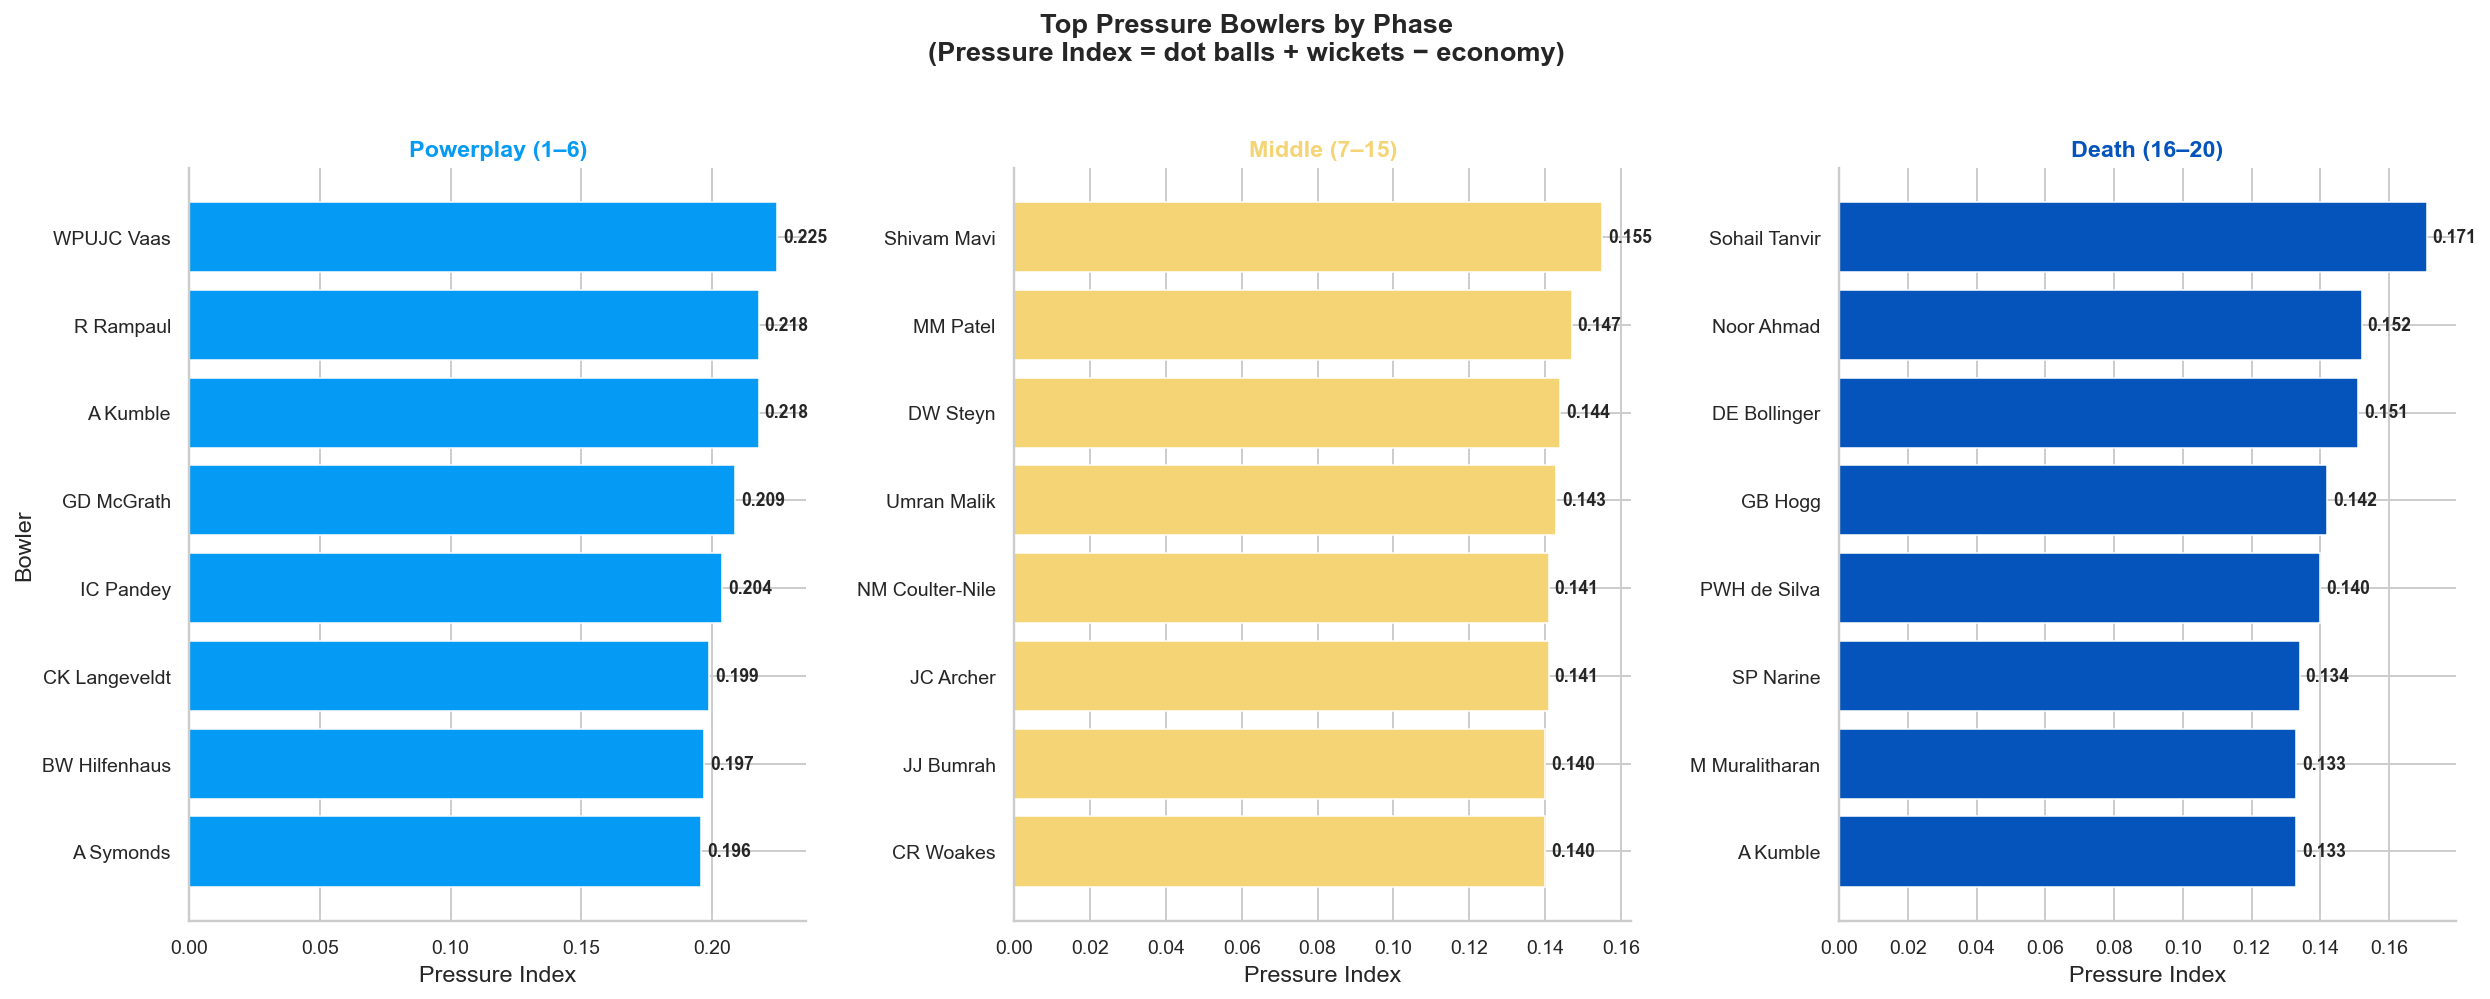

In [38]:
# Chart: Top 8 pressure bowlers per phase — 3 side-by-side panels
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

for ax, phase in zip(axes, phase_order):
    sub  = pressure_qual[pressure_qual["phase"] == phase]
    top8 = sub.nlargest(8, "pressure_index").sort_values("pressure_index")
    bars = ax.barh(top8["bowler"], top8["pressure_index"],
                   color=PHASE_PALETTE[phase], edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
    ax.set_title(phase, color=PHASE_PALETTE[phase], fontsize=12)
    ax.set_xlabel("Pressure Index")
    if ax == axes[0]:
        ax.set_ylabel("Bowler")
    sns.despine(ax=ax)

plt.suptitle(
    "Top Pressure Bowlers by Phase\n"
    "(Pressure Index = dot balls + wickets − economy)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{VISUALS}/strategy_08_pressure_index_by_phase.png", bbox_inches="tight")
plt.show()

## MODULE 5 — STRATEGY DASHBOARD

## One-page pre-match briefing dashboard with all key KPIs.

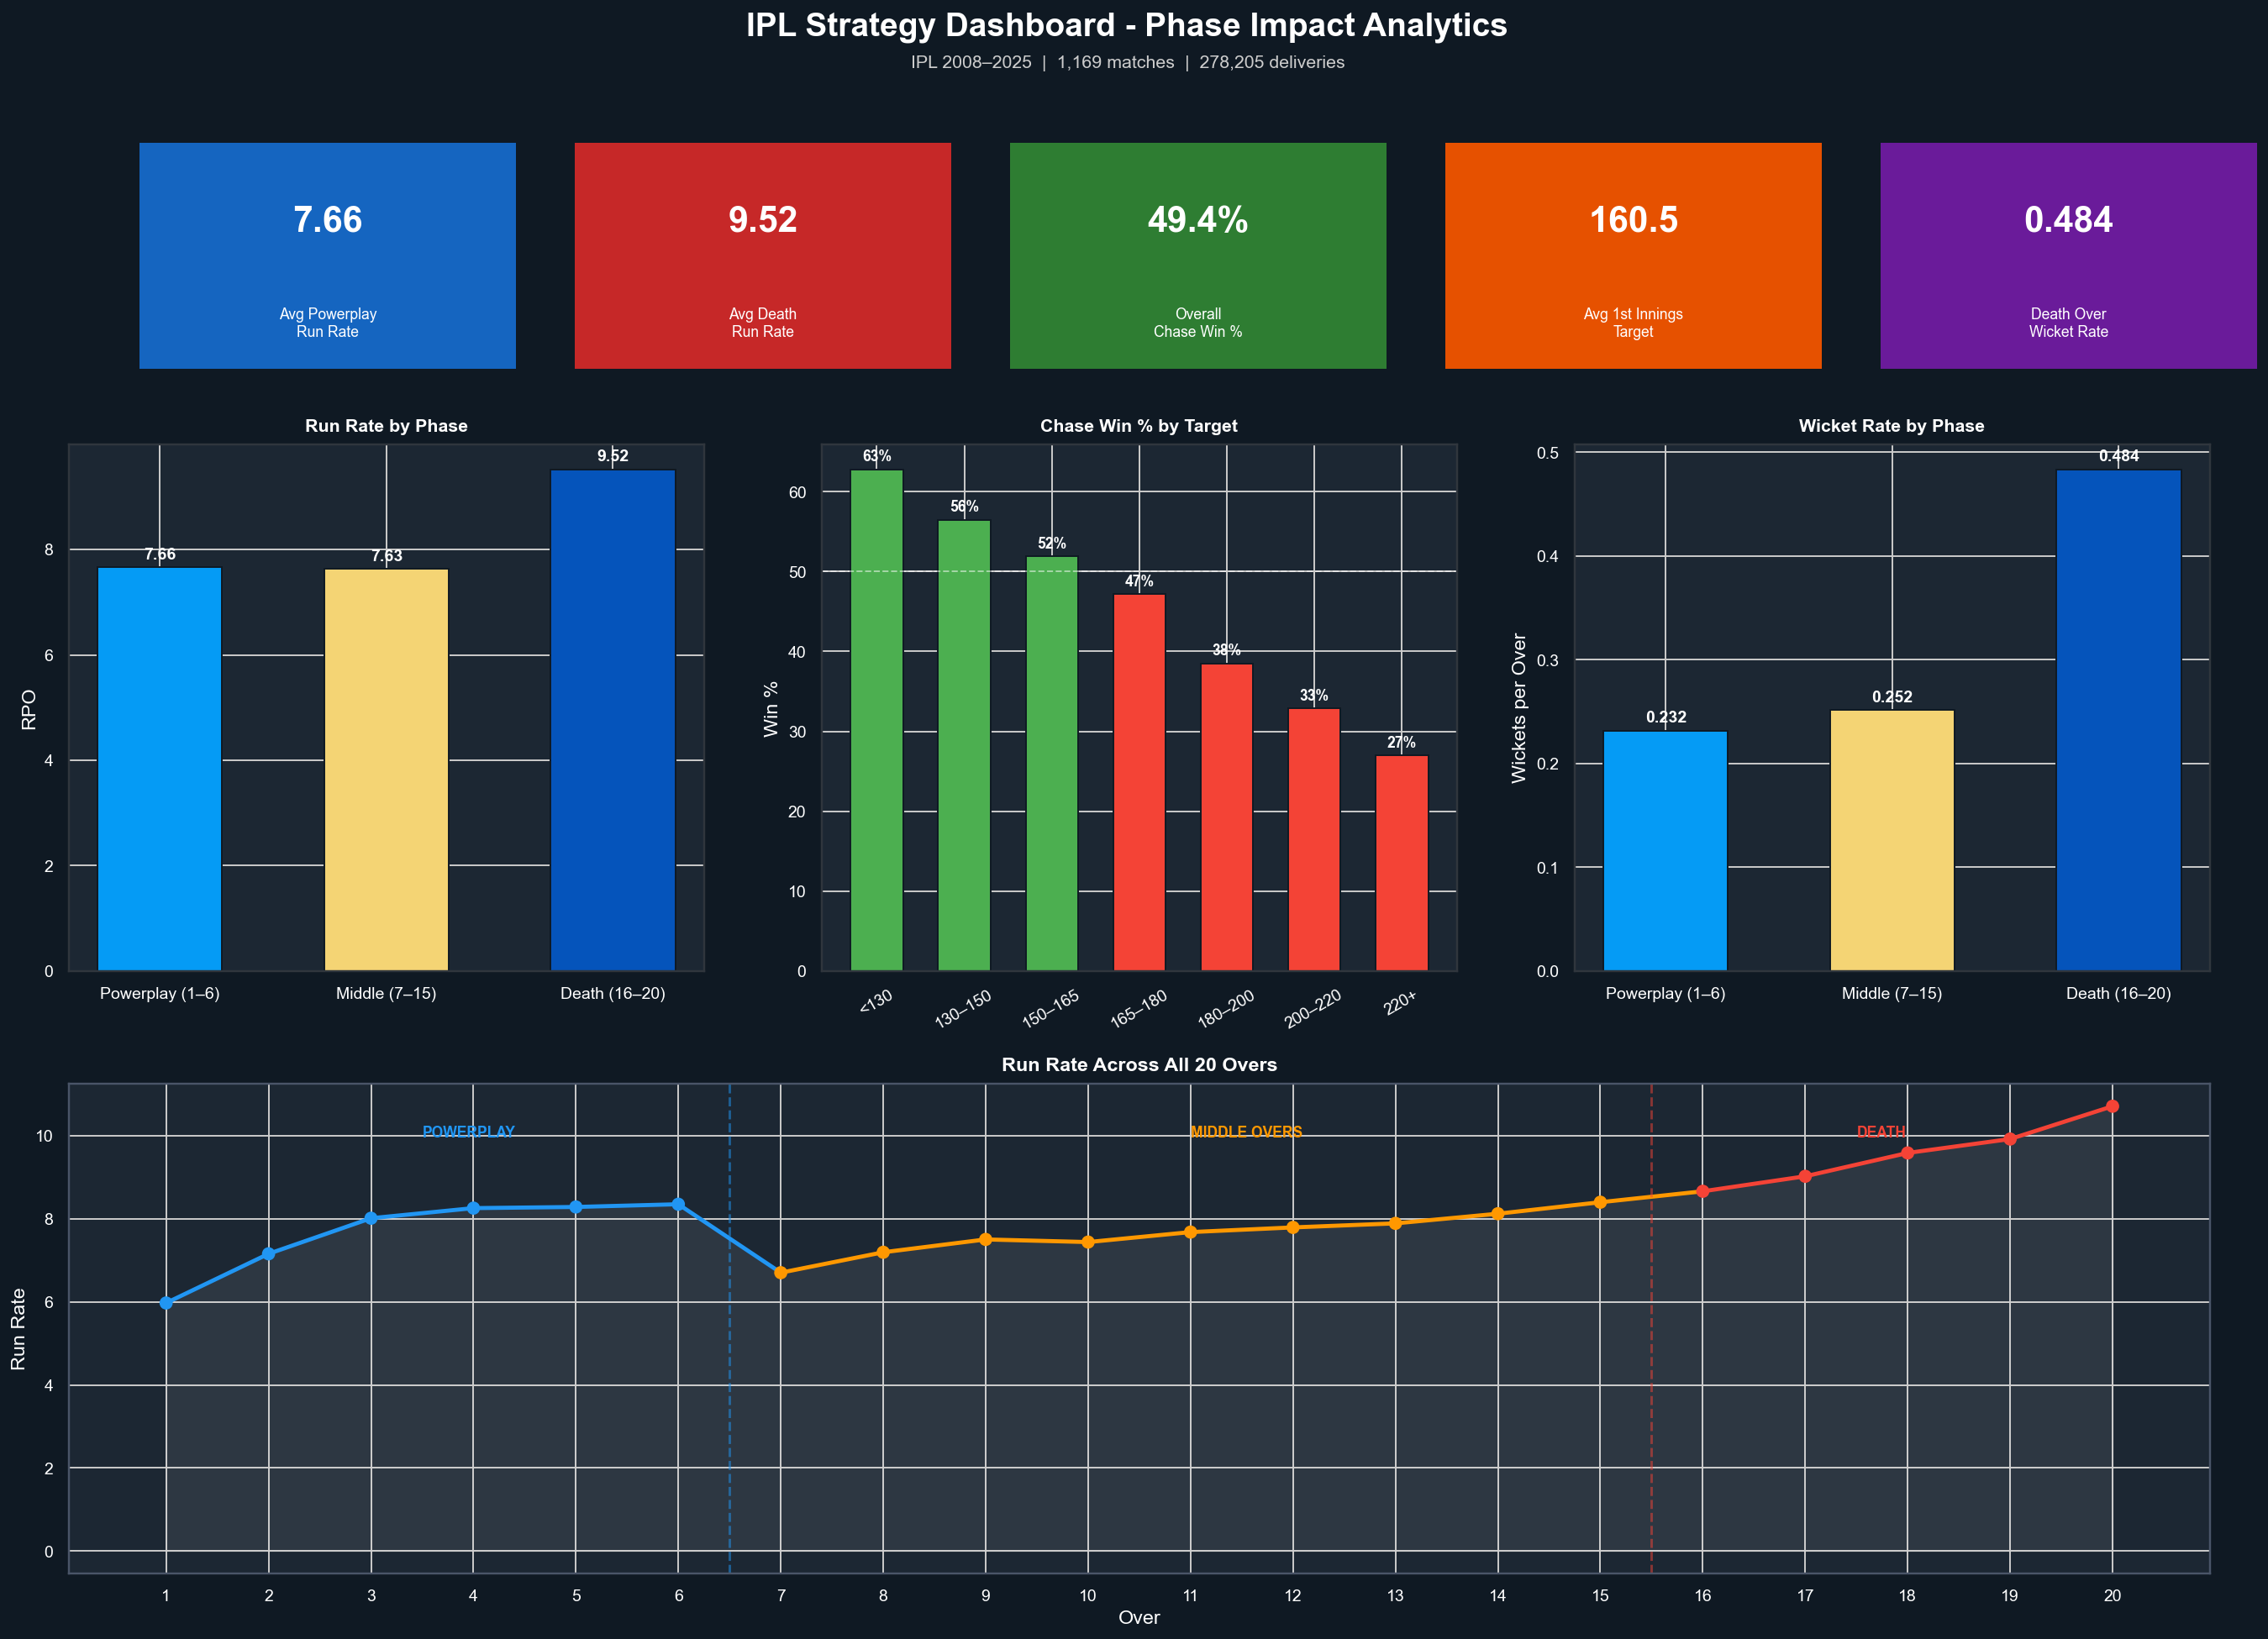

In [47]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#0f1923")

# Title
fig.text(0.5, 0.97,
         "IPL Strategy Dashboard - Phase Impact Analytics",
         ha="center", va="top", fontsize=20,
         fontweight="bold", color="white")
fig.text(0.5, 0.94,
         f"IPL 2008–2025  |  {df['match_id'].nunique():,} matches  |  {len(df):,} deliveries",
         ha="center", fontsize=11, color="#cccccc")

# KPI Cards
pp_df    = df[df["phase"] == "Powerplay (1–6)"]
death_df = df[df["phase"] == "Death (16–20)"]

kpis = [
    ("Avg Powerplay\nRun Rate",
     f"{pp_df['runs_total'].sum() / len(pp_df) * 6:.2f}",    "#1565C0"),
    ("Avg Death\nRun Rate",
     f"{death_df['runs_total'].sum() / len(death_df) * 6:.2f}", "#C62828"),
    ("Overall\nChase Win %",
     f"{match_info['chase_won'].mean() * 100:.1f}%",          "#2E7D32"),
    ("Avg 1st Innings\nTarget",
     f"{innings_summary[innings_summary['innings']==1]['final_score'].mean():.1f}", "#E65100"),
    ("Death Over\nWicket Rate",
     f"{death_df['is_wicket'].sum() / len(death_df) * 6:.3f}", "#6A1B9A"),
]

for i, (label, value, color) in enumerate(kpis):
    x_pos = 0.08 + i * 0.185
    ax_card = fig.add_axes([x_pos, 0.78, 0.16, 0.12])
    ax_card.set_facecolor(color)
    ax_card.set_xticks([])
    ax_card.set_yticks([])
    for spine in ax_card.spines.values():
        spine.set_visible(False)
    ax_card.text(0.5, 0.65, value,  ha="center", va="center",
                 fontsize=22, fontweight="bold", color="white",
                 transform=ax_card.transAxes)
    ax_card.text(0.5, 0.20, label,  ha="center", va="center",
                 fontsize=9,  color="white",
                 transform=ax_card.transAxes)

# Chart A: Run Rate by Phase
ax1 = fig.add_axes([0.05, 0.46, 0.27, 0.28])
ax1.set_facecolor("#1c2733")
phase_rr = (df.groupby("phase", observed=True)
               .agg(r=("runs_total","sum"), b=("runs_total","count"))
               .assign(rr=lambda x: x["r"] / x["b"] * 6)
               .reset_index())
b = ax1.bar(phase_rr["phase"], phase_rr["rr"],
            color=[PHASE_PALETTE[p] for p in phase_rr["phase"]],
            width=0.55, edgecolor="#0f1923")
ax1.bar_label(b, fmt="%.2f", padding=3, fontsize=10,
              fontweight="bold", color="white")
ax1.set_title("Run Rate by Phase", color="white", fontsize=11, pad=8)
ax1.tick_params(colors="white")
ax1.set_ylabel("RPO", color="white")
for sp in ax1.spines.values():
    sp.set_color("#30363d")

# Chart B: Chase Win % by Target
ax2 = fig.add_axes([0.37, 0.46, 0.27, 0.28])
ax2.set_facecolor("#1c2733")
c2 = ["#4CAF50" if p >= 50 else "#F44336" for p in bracket_wr["chase_win_pct"]]
b2 = ax2.bar(bracket_wr["target_bracket"], bracket_wr["chase_win_pct"],
             color=c2, width=0.6, edgecolor="#0f1923")
ax2.bar_label(b2, fmt="%.0f%%", padding=3, fontsize=9,
              fontweight="bold", color="white")
ax2.axhline(50, color="white", linestyle="--", lw=1, alpha=0.5)
ax2.set_title("Chase Win % by Target", color="white", fontsize=11, pad=8)
ax2.tick_params(colors="white")
ax2.xaxis.set_tick_params(rotation=30)
ax2.set_ylabel("Win %", color="white")
for sp in ax2.spines.values():
    sp.set_color("#30363d")

# Chart C: Wicket Rate by Phase
ax3 = fig.add_axes([0.69, 0.46, 0.27, 0.28])
ax3.set_facecolor("#1c2733")
pw = (df.groupby("phase", observed=True)["is_wicket"]
        .agg(w="sum", b="count")
        .assign(wr=lambda x: x["w"] / x["b"] * 6)
        .reset_index())
b3 = ax3.bar(pw["phase"], pw["wr"],
             color=[PHASE_PALETTE[p] for p in pw["phase"]],
             width=0.55, edgecolor="#0f1923")
ax3.bar_label(b3, fmt="%.3f", padding=3, fontsize=10,
              fontweight="bold", color="white")
ax3.set_title("Wicket Rate by Phase", color="white", fontsize=11, pad=8)
ax3.tick_params(colors="white")
ax3.set_ylabel("Wickets per Over", color="white")
for sp in ax3.spines.values():
    sp.set_color("#30363d")

# Sparkline: Over-by-over run rate
ax4 = fig.add_axes([0.05, 0.14, 0.91, 0.26])
ax4.set_facecolor("#1c2733")
ov = (df.groupby("over_cricket", observed=True)
        .agg(r=("runs_total","sum"), b=("runs_total","count"))
        .assign(rr=lambda x: x["r"] / x["b"] * 6)
        .reset_index())

c_line = ov["over_cricket"].apply(
    lambda o: "#2196F3" if o <= 6 else ("#FF9800" if o <= 15 else "#F44336")
)
for i in range(len(ov) - 1):
    ax4.plot(ov["over_cricket"].iloc[i:i+2], ov["rr"].iloc[i:i+2],
             color=c_line.iloc[i], lw=2.5)
ax4.scatter(ov["over_cricket"], ov["rr"], c=c_line, s=50, zorder=5)
ax4.fill_between(ov["over_cricket"], ov["rr"], alpha=0.08, color="white")
ax4.axvline(6.5,  color="#2196F3", lw=1.5, linestyle="--", alpha=0.5)
ax4.axvline(15.5, color="#F44336", lw=1.5, linestyle="--", alpha=0.5)
ax4.text(3.5,  ov["rr"].max() * 0.93, "POWERPLAY",
         color="#2196F3", fontsize=9, fontweight="bold")
ax4.text(11,   ov["rr"].max() * 0.93, "MIDDLE OVERS",
         color="#FF9800", fontsize=9, fontweight="bold")
ax4.text(17.5, ov["rr"].max() * 0.93, "DEATH",
         color="#F44336", fontsize=9, fontweight="bold")
ax4.set_title("Run Rate Across All 20 Overs",
              color="white", fontsize=12, pad=8)
ax4.set_xlabel("Over", color="white")
ax4.set_ylabel("Run Rate", color="white")
ax4.set_xticks(range(1, 21))
ax4.tick_params(colors="white")
for sp in ax4.spines.values():
    sp.set_color("#4a5568")

plt.savefig(f"{VISUALS}/strategy_9_dashboard.png",
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
